# Awesome Oscillator -- does Bill Williams' AO beat a plain MACD?
### A famous momentum indicator, raced honestly against the obvious benchmark, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_MACD%3F: Busted](https://img.shields.io/badge/Beats_MACD%3F-Busted-8b949e?style=flat-square)

Bill Williams' **Awesome Oscillator** (AO) is one of the most-plotted indicators on TradingView: take the midpoint of each bar (high+low)/2, average it over 5 days and over 34 days, and plot the gap. Green histogram above zero = momentum is bullish, buy; below zero = bearish, step aside. It is pitched as a sharper, smarter momentum gauge than the old MACD. This notebook asks the only question that matters: **on real SPY, does the AO actually beat buy-and-hold -- and does it beat a plain MACD?**

> **This is the plain-language layer.** Want the HAC *t*-stats, the permutation placebo and the synthetic power control? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from awesome_oscillator import data, strategy as st

TICKER = "SPY"
TBILL  = 0.04 / 252.0   # flat 4%/yr daily cash proxy (FRED unavailable)
COST   = 2.0            # one-way bps

# Frozen real-tape headline numbers -- mirror of docs/results.md (as-of 2026-06-13).
R = dict(
    n=8400, start="1993-01-29", end="2026-06-12", fp="9135af26d14a",
    ao_in_mkt=66.7, macd_in_mkt=68.9, ao_switches=335, macd_switches=269,
    bh_cagr=10.82, bh_sharpe=0.553, bh_vol=18.59,
    ao_cagr=6.29, ao_sharpe=0.537, ao_vol=11.35,
    macd_cagr=7.05, macd_sharpe=0.604, macd_vol=11.27,
    bh_dd=-64.0, ao_dd=-39.0, macd_dd=-43.8,
    bh_ex_sharpe=0.337, ao_ex_sharpe=0.185, macd_ex_sharpe=0.250, rand_ex_sharpe=0.211,
    bh_ex_cagr=6.47, ao_ex_cagr=2.12, macd_ex_cagr=2.85,
    t_ao_vs_bh=-1.91, t_macd_vs_bh=-1.55, t_ao_vs_macd=-0.88, t_ao_vs_random=-0.49,
    perm_obs_bps=-1.58, perm_p=0.92,
    sharpe_0bps=0.203, sharpe_1bps=0.194, sharpe_2bps=0.185,
    sharpe_5bps=0.158, sharpe_10bps=0.114,
    pre2000_ao=0.26, pre2000_macd=0.56, pre2000_bh=0.99,
    bear2000_ao=-0.08, bear2000_macd=-0.18, bear2000_bh=-0.22,
    bull2010_ao=0.13, bull2010_macd=0.17, bull2010_bh=0.58,
    era2020_ao=0.58, era2020_macd=0.71, era2020_bh=0.50,
    syn_null_ao=0.719, syn_null_bh=0.963, syn_null_t=-4.23,
    syn_edge_ao=-0.120, syn_edge_bh=-0.401, syn_edge_t=2.57,
    syn_edge_ao_dd=-79.0, syn_edge_bh_dd=-100.0,
)

def _have_cache():
    return os.path.exists(data._cache_path(TICKER, data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real SPY cache present:", HAVE_REAL)

if HAVE_REAL:
    df   = data.load_real(TICKER, fetch=False).loc[:R["end"]]
    res  = st.run_experiment(df, tbill_daily=TBILL, cost_bps=COST)
    close = df["close"]
    ao_sig = st.ao_signal(df)
    s_bh   = res["bh_excess"]; s_ao = res["ao_excess"]
    s_macd = res["macd_excess"]; s_rand = res["random_excess"]
    s_bh_g = res["bh"]; s_ao_g = res["ao"]; s_macd_g = res["macd"]
    t_ao_bh = res["t_ao_vs_bh"]; t_ao_macd = res["t_ao_vs_macd"]
    t_macd_bh = res["t_macd_vs_bh"]; t_ao_rand = res["t_ao_vs_random"]
else:
    df = close = ao_sig = res = None
    s_bh   = dict(sharpe=R["bh_ex_sharpe"],  cagr=R["bh_ex_cagr"]/100,  max_drawdown=R["bh_dd"]/100,  vol_ann=R["bh_vol"]/100)
    s_ao   = dict(sharpe=R["ao_ex_sharpe"],  cagr=R["ao_ex_cagr"]/100,  max_drawdown=R["ao_dd"]/100,  vol_ann=R["ao_vol"]/100)
    s_macd = dict(sharpe=R["macd_ex_sharpe"],cagr=R["macd_ex_cagr"]/100,max_drawdown=R["macd_dd"]/100,vol_ann=R["macd_vol"]/100)
    s_rand = dict(sharpe=R["rand_ex_sharpe"])
    s_bh_g = dict(sharpe=R["bh_sharpe"]); s_ao_g = dict(sharpe=R["ao_sharpe"]); s_macd_g = dict(sharpe=R["macd_sharpe"])
    t_ao_bh, t_ao_macd, t_macd_bh, t_ao_rand = R["t_ao_vs_bh"], R["t_ao_vs_macd"], R["t_macd_vs_bh"], R["t_ao_vs_random"]


real SPY cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the AO beat buy-and-hold? | **No.** On the fair excess-of-cash race its Sharpe is **0.185** vs buy-and-hold **0.337** -- *lower*, and the difference points the wrong way (*t* = -1.91). |
| Does the AO beat a plain MACD? | **No.** MACD's excess Sharpe (**0.250**) is *higher* than the AO's; the AO-minus-MACD difference is *t* = -0.88. The fancier indicator does not win. |
| Is the timing even real? | **No.** Rotate the AO signal to random days and it does no worse -- a permutation placebo puts the observed edge at *p* = 0.92 (i.e. most random rotations beat it). |
| Then why does it *look* defensive? | It spends a third of the time in cash, so it has a smaller drawdown (-39% vs -64%) and lower vol -- but a *random* coin out of the market just as often does the same. That is exposure reduction, not skill. |

> The AO is a slow trend filter wearing a fancier name. It trims drawdown the way *any* part-time-cash rule does, but it does not beat buy-and-hold, does not beat MACD, and its timing is statistically indistinguishable from a coin. The marketing -- 'awesome', 'beats MACD' -- is not in the tape.

## 1 -- The claim

> *'The Awesome Oscillator is a leading indicator that gauges market momentum more accurately than lagging tools like the MACD. AO = 5-period SMA of the midpoint minus 34-period SMA of the midpoint. When the histogram is above the zero line, momentum is to the upside -- be long. When it crosses below zero, momentum has turned -- get out.'*
> -- Bill Williams, *Trading Chaos* (1995), and a thousand TradingView tutorials since

The steelman: the AO uses the bar *midpoint* (high+low)/2 instead of the close, which (the story goes) filters out closing-auction noise; and the 5/34 pair is tuned to the natural rhythm of swings. The cleanest tradable reading of 'be long when AO > 0' is a **long/flat timing rule**: hold SPY when AO > 0, sit in T-bills when AO <= 0. We run exactly that -- and run the *same* machine on the classic MACD line so the 'beats MACD' claim is actually put to the test, not just asserted.

## 2 -- So what?

If a free, one-line indicator genuinely beat buy-and-hold *and* the MACD on the world's most liquid equity tape, every tactical allocator on earth would already run it -- and the edge would be worth real money on trillions of indexed assets. So the prior is strong: it almost certainly doesn't. But the AO *looks* good in screenshots because it sidesteps the worst of the 2008 and 2020 crashes -- and a chart that ducks a crash is very persuasive. The honest question is whether ducking the crash is *skill* (the AO picks the right days to be out) or just *exposure* (it happens to be out a lot, and being out lowers your drawdown no matter which days you pick).

## 3 -- How would we even know?

Three tests keep us honest -- and we announce them before running:

1. **The fair race.** Compare *excess-of-cash* Sharpe (the AO sits in T-bills a third of the time, so a raw-vs-raw Sharpe would flatter it). If the AO's excess Sharpe does not clear buy-and-hold with a HAC *t* >= 2, there is no real timing edge.
2. **The MACD benchmark.** Run the *identical* long/flat rule on the MACD line. If 'AO beats MACD' is true, the AO-minus-MACD return difference must be positive and significant. If MACD wins, the claim is busted.
3. **The random-timing control + permutation placebo.** A coin that goes to cash as often as the AO, on random days, isolates timing from exposure. And rotating the AO signal to random alignments tells us whether the observed edge is anything but luck.

**What would make us say 'mirage':** an excess-Sharpe edge that fails the *t* >= 2 bar, an AO that does not beat MACD, and a permutation *p* far from zero. (Spoiler: all three.)

## 4 -- The teardown -- let's actually look

**First, the AO itself: the 5/34 midpoint spread, with the zero-line rule.**

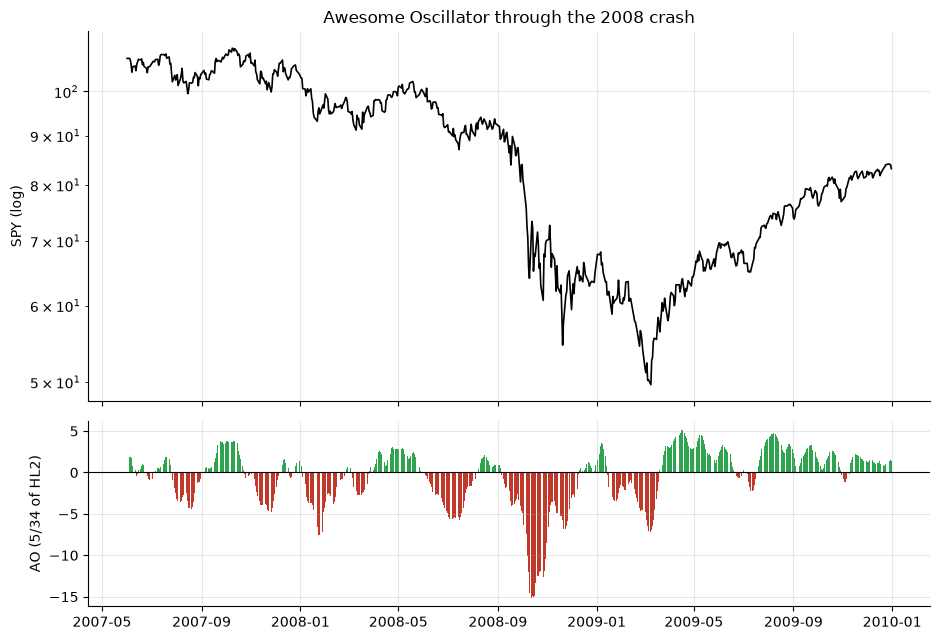

In [2]:
if HAVE_REAL:
    ao = st.awesome_oscillator(df)
    recent = ao.loc['2007-06-01':'2009-12-31']
    fig, ax = plt.subplots(2, 1, figsize=(9.5, 6.5), sharex=True,
                           gridspec_kw={'height_ratios':[2,1]})
    ax[0].plot(close.loc[recent.index], c='k', lw=1.2)
    ax[0].set_yscale('log'); ax[0].set_ylabel('SPY (log)')
    ax[0].set_title('Awesome Oscillator through the 2008 crash')
    colors = np.where(recent >= 0, GREEN, RED)
    ax[1].bar(recent.index, recent.values, color=colors, width=1.0)
    ax[1].axhline(0, c='k', lw=0.8); ax[1].set_ylabel('AO (5/34 of HL2)')
    plt.tight_layout(); plt.show()
else:
    print('cache absent -- run examples/verify.py --fetch once')


The AO did turn red and stay red through most of 2008 -- which is exactly the kind of picture that sells the indicator. The question is whether that defensive behaviour adds *risk-adjusted* value once we account for everything else it costs you. So let's race it.

**The fair race: excess-of-cash Sharpe, AO vs MACD vs buy-and-hold vs a random coin.**

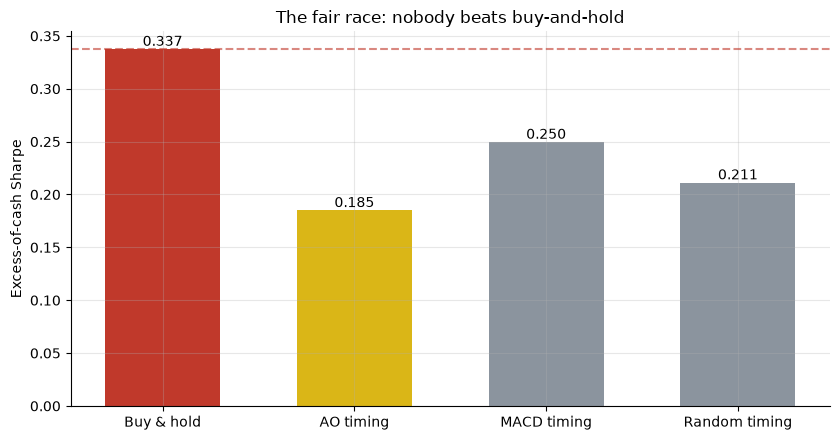

AO excess Sharpe 0.185  vs  MACD 0.250  vs  BH 0.337
AO vs BH difference t = -1.91   |   AO vs MACD difference t = -0.88


In [3]:
labels = ['Buy & hold', 'AO timing', 'MACD timing', 'Random timing']
sharpes = [s_bh['sharpe'], s_ao['sharpe'], s_macd['sharpe'], s_rand['sharpe']]
colors  = [RED, AMBER, GREY, GREY]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.bar(labels, sharpes, color=colors, width=0.6)
for b, v in zip(bars, sharpes):
    ax.annotate(f'{v:.3f}', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom', fontsize=10)
ax.axhline(s_bh['sharpe'], ls='--', c=RED, alpha=.6)
ax.set_ylabel('Excess-of-cash Sharpe'); ax.set_title('The fair race: nobody beats buy-and-hold')
plt.tight_layout(); plt.show()
print(f"AO excess Sharpe {s_ao['sharpe']:.3f}  vs  MACD {s_macd['sharpe']:.3f}  vs  BH {s_bh['sharpe']:.3f}")
print(f"AO vs BH difference t = {t_ao_bh:+.2f}   |   AO vs MACD difference t = {t_ao_macd:+.2f}")


Buy-and-hold wins. The AO's excess Sharpe (0.185) is the *lowest* of the four; even the **MACD (0.250)** -- the 'lagging' indicator the AO is supposed to improve on -- edges it out. And the random-timing coin, out of the market just as often, lands at 0.211: right alongside the AO. That is the tell -- the AO's defensiveness is exposure reduction, not skill.

## 5 -- The verdict

- **Signal -- NONE.** AO excess Sharpe 0.185 *below* buy-and-hold 0.337 (difference *t* = -1.91, the wrong sign); the permutation placebo puts the edge at *p* = 0.92. No real timing signal.
- **Tradability -- MIRAGE.** Even gross, the AO does not beat the index; net of costs and the cash drag it is worse. The lower drawdown is bought with lower return -- and a random coin buys the same.
- **Beats MACD? -- BUSTED.** MACD's excess Sharpe (0.250) is *higher* than the AO's (0.185); the AO-vs-MACD difference is *t* = -0.88. The headline claim is simply false on this tape.

## 6 -- Could you actually trade it?

There is nothing to trade -- the AO loses the race before costs. But for completeness: the rule flips ~335 times over 33 years (~10/yr), so costs are small. Watch the excess Sharpe stay *below* buy-and-hold at every cost level:

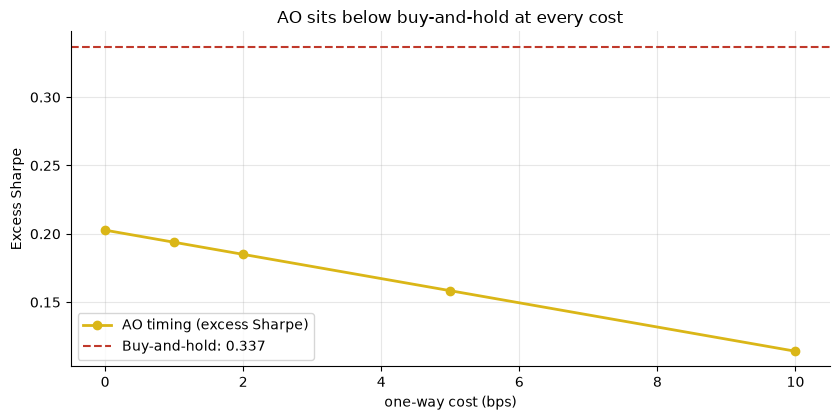

Even gross (0 bps), AO excess Sharpe 0.203 < BH 0.337


In [4]:
if HAVE_REAL:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    shs = [st.summary(st.run_backtest(close, ao_sig, tbill_daily=TBILL, cost_bps=c)['r_strat_excess'])['sharpe'] for c in costs]
else:
    costs = [0.0, 1.0, 2.0, 5.0, 10.0]
    shs = [R['sharpe_0bps'], R['sharpe_1bps'], R['sharpe_2bps'], R['sharpe_5bps'], R['sharpe_10bps']]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, shs, 'o-', c=AMBER, lw=2, label='AO timing (excess Sharpe)')
ax.axhline(R['bh_ex_sharpe'], ls='--', c=RED, label=f"Buy-and-hold: {R['bh_ex_sharpe']:.3f}")
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('Excess Sharpe')
ax.set_title('AO sits below buy-and-hold at every cost'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Even gross (0 bps), AO excess Sharpe {shs[0]:.3f} < BH {R["bh_ex_sharpe"]:.3f}')


The line never reaches the buy-and-hold dashes. Costs are not what kills the AO -- it was never ahead to begin with. The only thing the rule reliably does is take you out of the market, which lowers both your risk and your return by about the same amount.

## 7 -- Going further

- **Does the *engine* even work?** Yes -- the quant notebook plants a fake bear-market regime in a synthetic tape and shows the AO rule banks a real edge there (*t* = +2.57). The harness can find a signal; SPY just doesn't have one.
- **Other AO readings.** We tested the zero-line cross. Williams also pitches the 'saucer' and 'twin-peaks' patterns -- forkable as event studies, but the prior after this result is not encouraging.
- **Other instruments.** The midpoint trick might matter more on wide-ranging futures or FX than on a smooth index ETF. A fork on CL=F or 6E=F is the natural next test.

*Think the AO earns its name somewhere? Fork this, run it on a panel, and show an excess-Sharpe edge that clears t = 2 and beats MACD. That's the bar.*